In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [27]:
df = pd.read_csv("data/AB_NYC_2019.csv")

In [28]:
print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [30]:
print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          1.000000           0.00

In [31]:
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


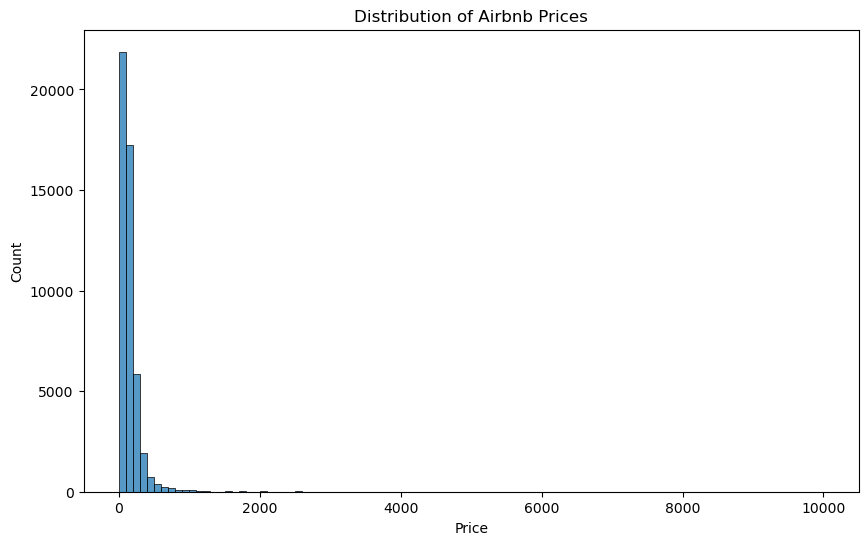

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=100)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [33]:
df = df[df['price'] < 1000]

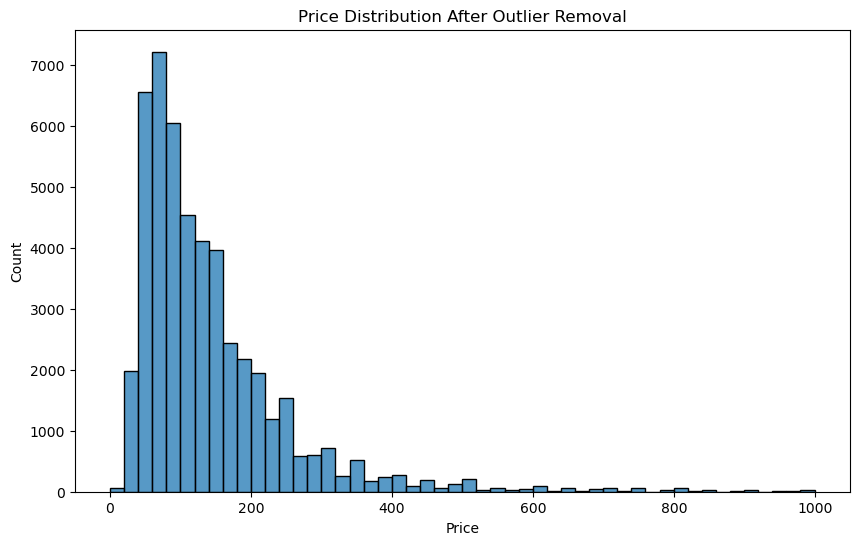

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=50)

plt.title("Price Distribution After Outlier Removal")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

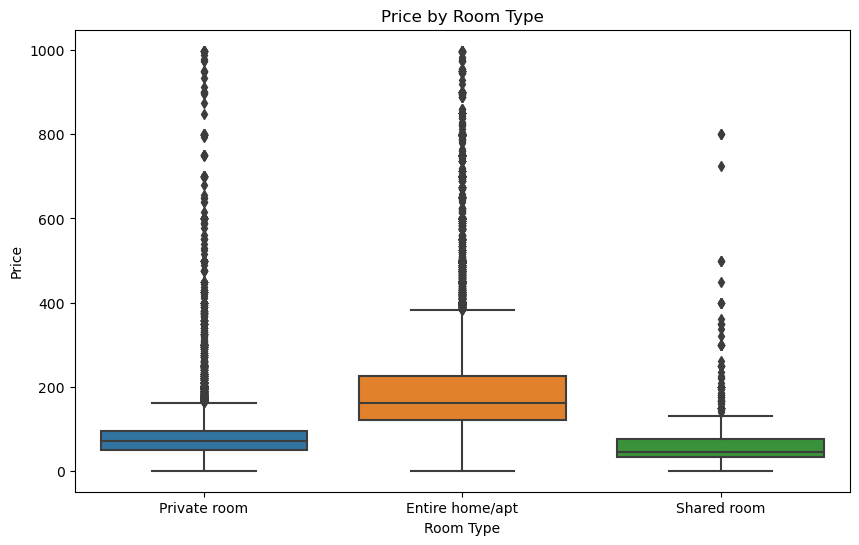

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(x='room_type', y='price', data=df)

plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.show()

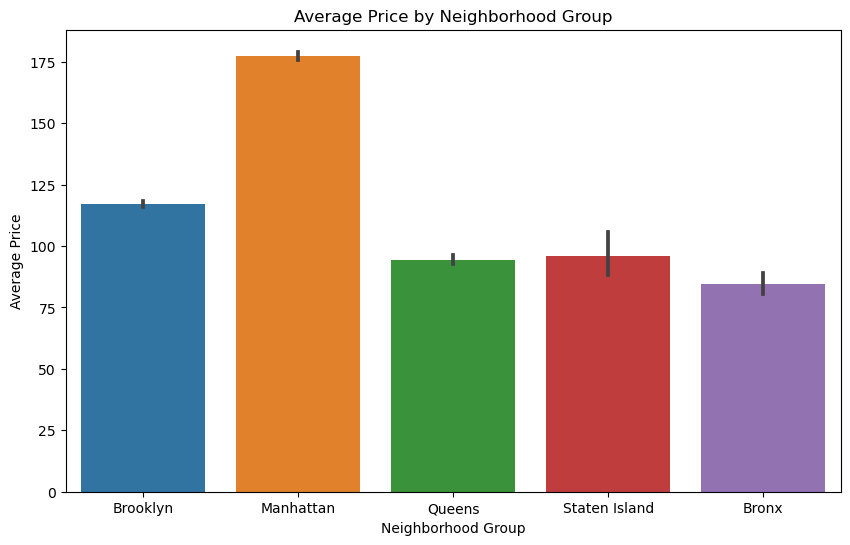

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='neighbourhood_group',
    y='price',
    data=df
)

plt.title("Average Price by Neighborhood Group")
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price")

plt.show()

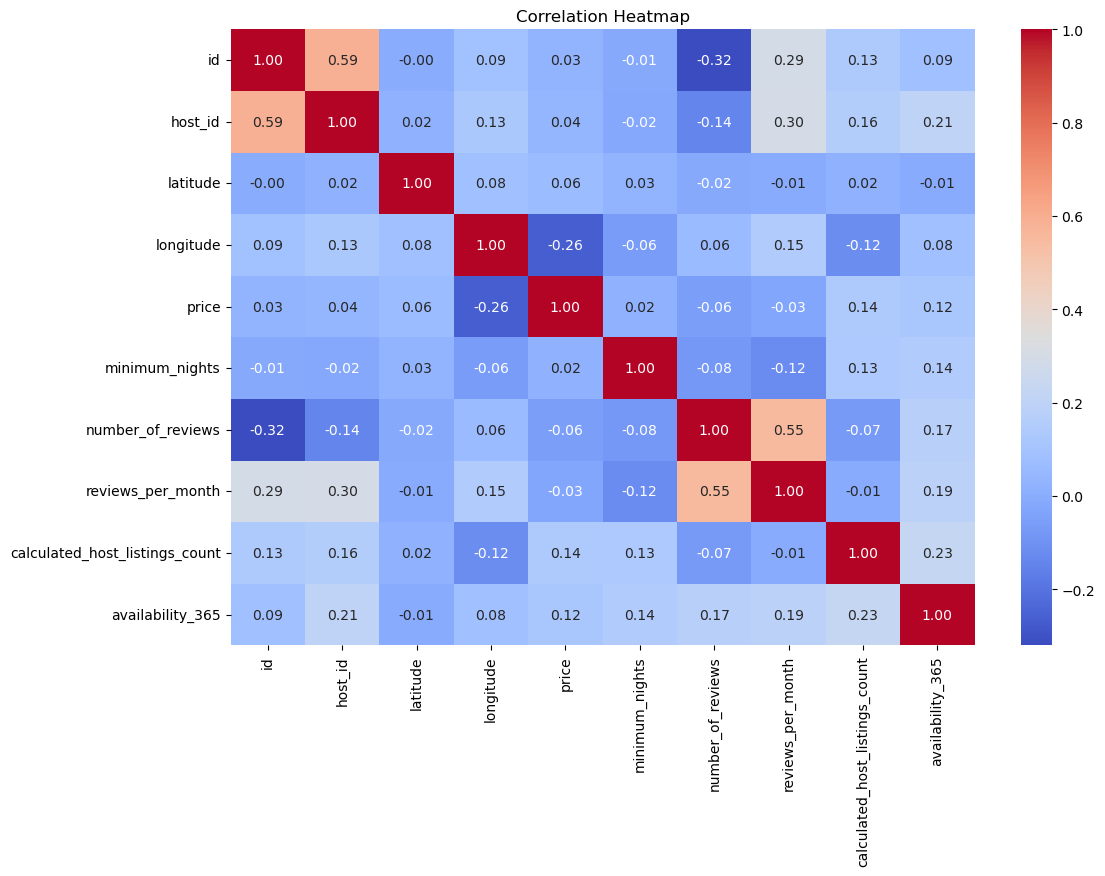

In [37]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

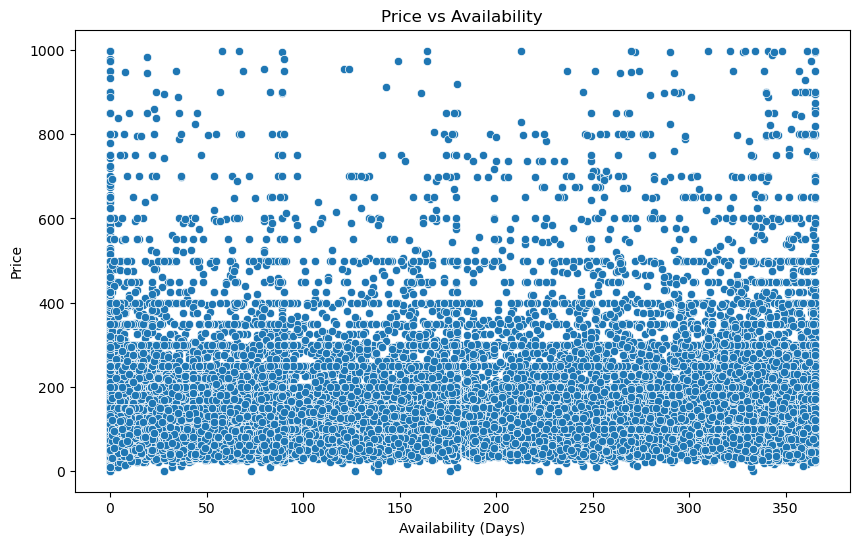

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='availability_365',
    y='price',
    data=df
)

plt.title("Price vs Availability")
plt.xlabel("Availability (Days)")
plt.ylabel("Price")

plt.show()

In [39]:
print(df.isnull().sum())

id                                   0
name                                16
host_id                              0
host_name                           21
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9891
reviews_per_month                 9891
calculated_host_listings_count       0
availability_365                     0
dtype: int64


In [40]:
df = df.dropna()

In [41]:
features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'room_type',
    'neighbourhood_group'
]

X = df[features]
y = df['price']

In [42]:
X = pd.get_dummies(X, drop_first=True)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)

In [46]:
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Results
MAE: 52.92774476874097
RMSE: 90.64513297384678
R²: 0.3109100334347795


In [47]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 46.105504717590804
RMSE: 81.18547353438579
R²: 0.44723109838119857


In [49]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_preds = gb.predict(X_test)

In [50]:
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting Results
MAE: 47.55108025259358
RMSE: 84.60275167122542
R²: 0.39971716810351565


In [51]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R²': [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

print(results)

               Model        MAE       RMSE        R²
0  Linear Regression  52.927745  90.645133  0.310910
1      Random Forest  46.105505  81.185474  0.447231
2  Gradient Boosting  47.551080  84.602752  0.399717


In [52]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
7           room_type_Private room    0.218098
1                        longitude    0.195869
0                         latitude    0.159744
6                 availability_365    0.119172
4                reviews_per_month    0.090656
3                number_of_reviews    0.074594
2                   minimum_nights    0.066138
5   calculated_host_listings_count    0.039342
8            room_type_Shared room    0.029348
10   neighbourhood_group_Manhattan    0.003875


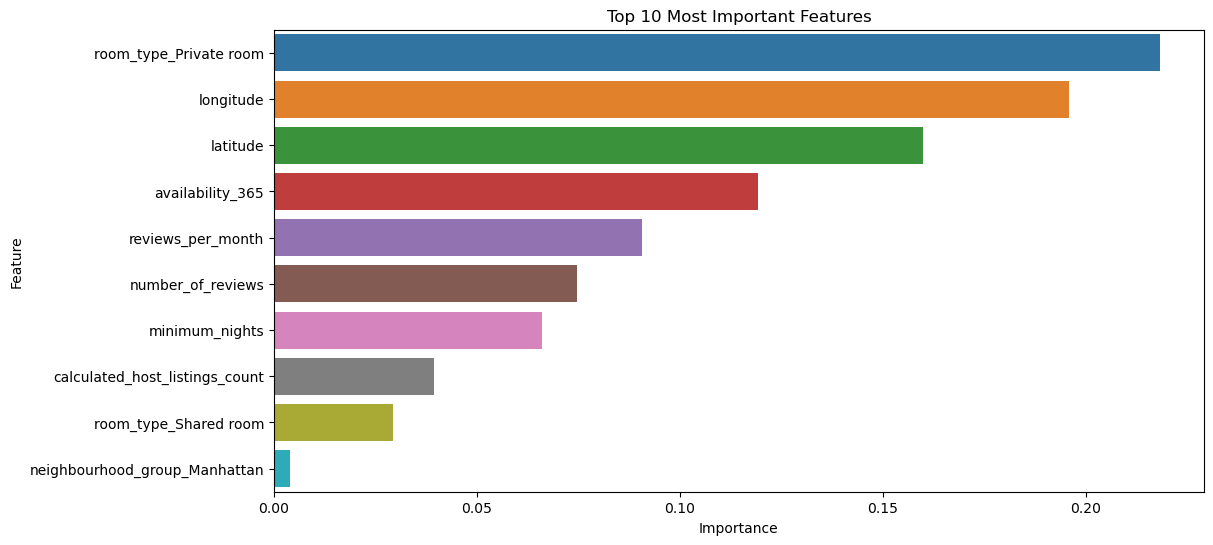

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()